### [ 블러링- 미디언 블러/ 양방향 필터 ] <hr>
- 이미지에 작은 흰색 점, 검은 점 제거=> 미디언 블러
    * 컨볼루션 연산 수행 X
    * 커널 용도: 범위 지정=> 이미지 픽셀들
    * 픽셀들 오름차순 정렬=> 중앙값 추출=> 픽셀 가운데 픽셀값 교체
    
- 이미지의 노이즈 제거 후 추가로 경계선 선명히 해주는 양방향 필터


In [2]:
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils


import importlib
import cv_utils

importlib.reload(cv_utils)

from cv_utils import *
importlib.reload(cv_utils)



<module 'cv_utils' from 'C:\\KDT14\\7_CV\\cv_utils.py'>

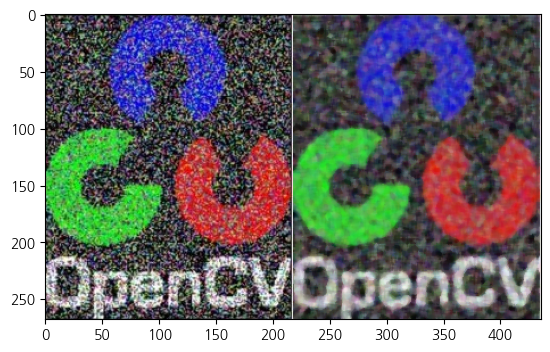

In [8]:

img = cv2.imread("../Images/salt_pepper_noise.jpg")

# 미디언 블러 적용 --- ①
blur = cv2.medianBlur(img, 5)

# 결과 출력 
merged = np.hstack((img,blur))


plt.imshow(cv2.cvtColor(merged, cv2.COLOR_RGB2BGR))


imgNP   => (268, 218, 3),   0,   255
medNP03 => (268, 218, 3),  0,  255
medNP05 => (268, 218, 3),  2,  246
medNP07 => (268, 218, 3),  5,  243


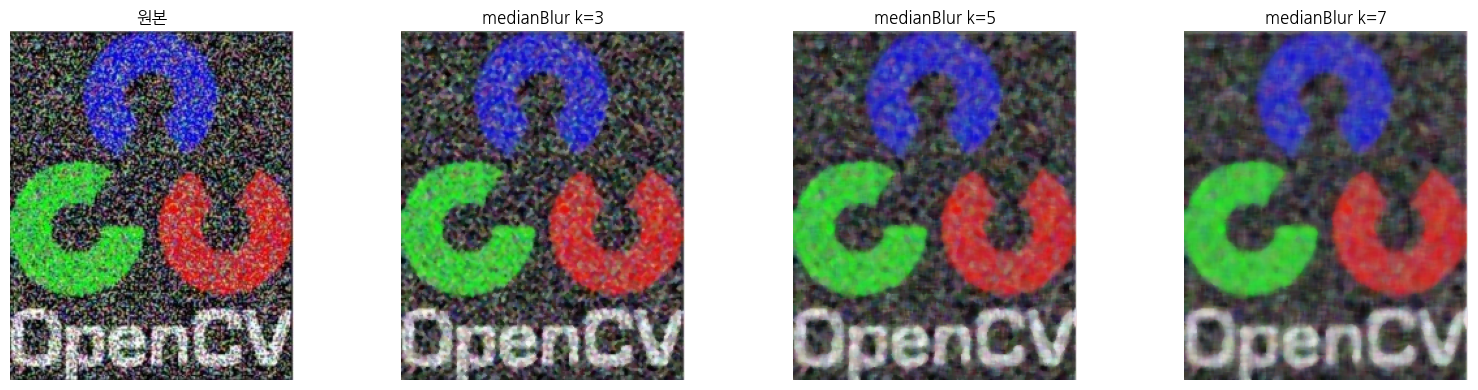

In [11]:
import cv2
import matplotlib.pyplot as plt

## 미디언블러 처리
medNP03 = cv2.medianBlur(img, 3)
medNP05 = cv2.medianBlur(img, 5)
medNP07 = cv2.medianBlur(img, 7)

print(f'imgNP   => {img.shape},   {img.min()},   {img.max()}')
print(f'medNP03 => {medNP03.shape},  {medNP03.min()},  {medNP03.max()}')
print(f'medNP05 => {medNP05.shape},  {medNP05.min()},  {medNP05.max()}')
print(f'medNP07 => {medNP07.shape},  {medNP07.min()},  {medNP07.max()}')

## ==============================
## plt 시각화
## ==============================

titles = ['원본', 'medianBlur k=3', 'medianBlur k=5', 'medianBlur k=7']
images = [img, medNP03, medNP05, medNP07]

plt.figure(figsize=(16, 4))

for i, (title, img) in enumerate(zip(titles, images)):
    plt.subplot(1, 4, i + 1)
    plt.title(title)

    # 컬러 이미지이면 BGR -> RGB 변환해서 출력
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')

    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
## ================================================
## 커널 생성: n에 따른 6개 커널
## ================================================

value= np.array([[1, 1, 1],
                 [1, 1, 1], 
                 [1, 1, 1]])

ns= [1, 2, 4, 9, 13, 15]

kernels= [value/n for n in ns]

for k, n in zip(kernels, ns):
    print(f'\nn={n} 커널===> \n {k}')


n=1 커널===> 
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

n=2 커널===> 
 [[0.5 0.5 0.5]
 [0.5 0.5 0.5]
 [0.5 0.5 0.5]]

n=4 커널===> 
 [[0.25 0.25 0.25]
 [0.25 0.25 0.25]
 [0.25 0.25 0.25]]

n=9 커널===> 
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

n=13 커널===> 
 [[0.07692308 0.07692308 0.07692308]
 [0.07692308 0.07692308 0.07692308]
 [0.07692308 0.07692308 0.07692308]]

n=15 커널===> 
 [[0.06666667 0.06666667 0.06666667]
 [0.06666667 0.06666667 0.06666667]
 [0.06666667 0.06666667 0.06666667]]


### [ 양방향 필터 ] <hr>
- 선택된 픽셀에서 중앙 픽셀을 기준으로 거리, 색상 차에 따른 가중치 부여
    * [거리] 중심 픽셀-> 가까운 픽셀: 가중치 ↑ | 멀리 있는 픽셀은 가중치 ↓
    * [색상] 중심 픽셀-> 비슷한 색상: 가중치 ↑ | 색상값 다른 픽셀: 가중치 ↓

- 고정된 값의 커널 없음
    * 매번 중심 픽셀이 변경되기 때문에 매번 계산 필요
    
- 픽셀의 색상차를 고려하기 때문에 경계 부분이 덜 흐려짐(유지됨)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

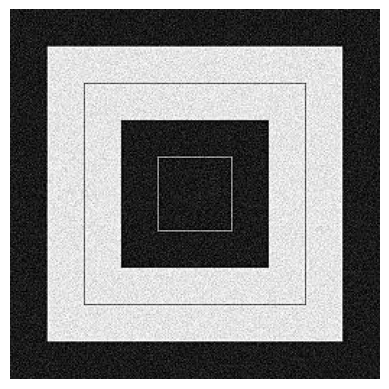

In [12]:
IMG_FILE= '../Images/gaussian_noise.jpg'
img= cv2.imread(IMG_FILE)

plt.imshow(img)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

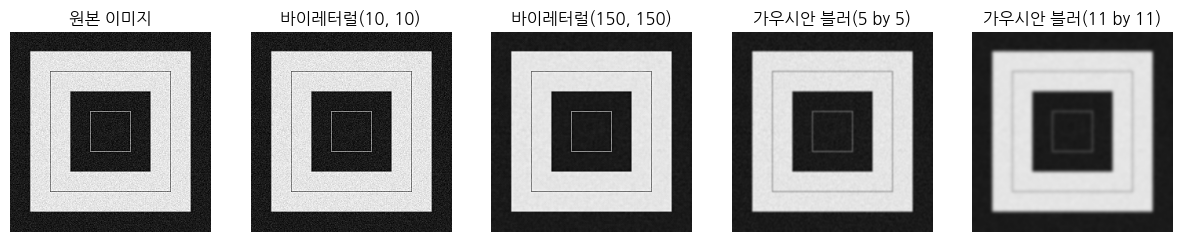

In [16]:

# 바이레터럴(75 by 75)
conblur1= cv2.bilateralFilter(img, 5, 10, 10)

# 바이레터럴(150 by 150)
conblur2= cv2.bilateralFilter(img, 5, 150, 150)

# 가우시안 블러(5 by 5)
conblur3= cv2.GaussianBlur(img, (5, 5), 0)

# 가우시안 블러(11 by 11)
conblur4= cv2.GaussianBlur(img, (11,11), 0)




plt.figure(figsize=(15, 5))

plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("원본 이미지")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(cv2.cvtColor(conblur1, cv2.COLOR_RGB2BGR))
plt.title("바이레터럴(10, 10)")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(conblur2)
plt.title("바이레터럴(150, 150)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(conblur3)
plt.title("가우시안 블러(5 by 5)")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(conblur4)
plt.title("가우시안 블러(11 by 11)")
plt.axis("off")

